In [2]:
import os
from collections import Counter

import numpy as np
from scipy.sparse import coo_matrix
from sklearn.decomposition import TruncatedSVD
PROJECT_DIR = "/Users/ppers/scientific_work/create-complete-lang/"
BASE = PROJECT_DIR + "data/corpora/marathi/news_leipzig/mar_news_2010_300K"

WORDS_FILE = BASE + "-words.txt"
CO_S_FILE   = BASE + "-co_s.txt"

MAX_VOCAB = 50000
MIN_WORD_ID = 101

N_COMPONENTS = 300



In [3]:
word_ids = []
word_strings = []
word_freqs = []

with open(WORDS_FILE, encoding="utf-8") as f:
    for line in f:
        # формат: word_id word frequency (разделитель — пробел/таб)
        parts = line.rstrip("\n").split()
        if len(parts) != 3:
            continue
        wid_str, word, freq_str = parts
        wid  = int(wid_str)
        freq = int(freq_str)
        word_ids.append(wid)
        word_strings.append(word)
        word_freqs.append(freq)

len(word_ids), word_ids[:5], word_strings[:5], word_freqs[:5]


(290031, [1, 2, 3, 4, 5], ['!', '"', '#', '$', '%'], [5649, 108, 47, 0, 93])

In [4]:
id2index = {}    # word_id → 0..V-1
index2id = []    # индекс → word_id
index2word = []  # индекс → строка слова

for wid, word, freq in zip(word_ids, word_strings, word_freqs):
    if wid < MIN_WORD_ID:
        continue  # пропускаем служебные ID
    if len(index2word) >= MAX_VOCAB:
        break
    idx = len(index2word)
    id2index[wid] = idx
    index2id.append(wid)
    index2word.append(word)

V = len(index2word)
print(f"Размер словаря для SVD: {V}")
print("Примеры слов:", index2word[:20])


Размер словаря для SVD: 50000
Примеры слов: ['आहे', 'या', 'आणि', 'व', 'नाही', 'यांनी', 'आहेत', 'हे', 'तर', 'होते', 'ते', 'असे', 'करण्यात', 'हा', 'ही', 'केली', 'केले', 'काही', 'एक', 'ऑगस्ट']


In [5]:
rows = []
cols = []
data = []

n_lines = 0
n_used  = 0

with open(CO_S_FILE, encoding="utf-8") as f:
    for line in f:
        n_lines += 1
        parts = line.rstrip("\n").split()
        if len(parts) != 4:
            continue
        w1_id_str, w2_id_str, count_str, sig_str = parts

        w1_id = int(w1_id_str)
        w2_id = int(w2_id_str)

        if w1_id not in id2index or w2_id not in id2index:
            continue

        i = id2index[w1_id]
        j = id2index[w2_id]
        count = int(count_str)

        rows.append(i)
        cols.append(j)
        data.append(count)

        rows.append(j)
        cols.append(i)
        data.append(count)

        n_used += 1

print(f"Всего строк в co_s: {n_lines}")
print(f"Использовано пар (до симметрии): {n_used}")
print(f"Ненулевых элементов в матрице (после симметрии): {len(data)}")

X = coo_matrix((data, (rows, cols)), shape=(V, V), dtype=np.float32).tocsr()
X


Всего строк в co_s: 2841216
Использовано пар (до симметрии): 2311292
Ненулевых элементов в матрице (после симметрии): 4622584


<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 2311292 stored elements and shape (50000, 50000)>

In [6]:
svd = TruncatedSVD(
    n_components=N_COMPONENTS,
    algorithm="randomized",
    n_iter=5,
    random_state=0,
)

word_vectors = svd.fit_transform(X)

print("Форма матрицы X:", X.shape)
print("Форма матрицы word_vectors:", word_vectors.shape)


Форма матрицы X: (50000, 50000)
Форма матрицы word_vectors: (50000, 300)


In [7]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# строим отображение слово -> индекс
word2idx = {w: i for i, w in enumerate(index2word)}

def nearest_neighbors(word, topn=10):
    """Возвращает topn ближайших соседей по косинусному сходству для заданного слова."""
    if word not in word2idx:
        print(f"Слова '{word}' нет в словаре (топ-{len(index2word)}).")
        return []
    i = word2idx[word]
    v = word_vectors[i : i+1]  # (1 × d)
    sims = cosine_similarity(v, word_vectors)[0]  # (vocab_size,)

    order = np.argsort(-sims)
    result = []
    for j in order:
        if j == i:
            continue
        result.append((index2word[j], float(sims[j])))
        if len(result) >= topn:
            break
    return result


In [8]:
test_words = [
    "राजा",   # король
    "सरकार", # правительство
    "भारत",  # Индия
]

for w in test_words:
    print("=" * 40)
    print("Слово:", w)
    neighbors = nearest_neighbors(w, topn=3)
    for nb, sim in neighbors:
        print(f"  {nb:15s}  {sim:.3f}")


Слово: राजा
  रसाळ             0.783
  नायक             0.761
  झंझावाती         0.751
Слово: सरकार
  शासन             0.831
  होत              0.827
  न्याय            0.815
Слово: भारत
  दक्षिण           0.888
  समाज             0.881
  अत्यंत           0.881


In [9]:
import numpy as np

# Если index2word отсортирован по частоте, возьмём, например, первые 300 слов
N_VIS = 300
words_subset = index2word[:N_VIS]

# Строим отображение слово -> индекс
word2idx = {w: i for i, w in enumerate(index2word)}

# Выбираем вектора для поднабора
indices = [word2idx[w] for w in words_subset]
vectors_subset = word_vectors[indices]
vectors_subset.shape


(300, 300)

In [10]:
words_subset = [
    "राजा", "राणी", "मुंबई", "पुणे", "सरकार", "मंत्री", "भारत", "पाकिस्तान",
]
words_subset = [w for w in words_subset if w in word2idx]
indices = [word2idx[w] for w in words_subset]
vectors_subset = word_vectors[indices]


/Users/ppers/scientific_work/create-complete-lang/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ppers/scientific_work/create-complete-lang/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ppers/scientific_work/create-complete-lang/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2366 (\N{DEVANAGARI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ppers/scientific_work/create-complete-lang/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2332 (\N{DEVANAGARI LETTER JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ppers/scientific_work/crea

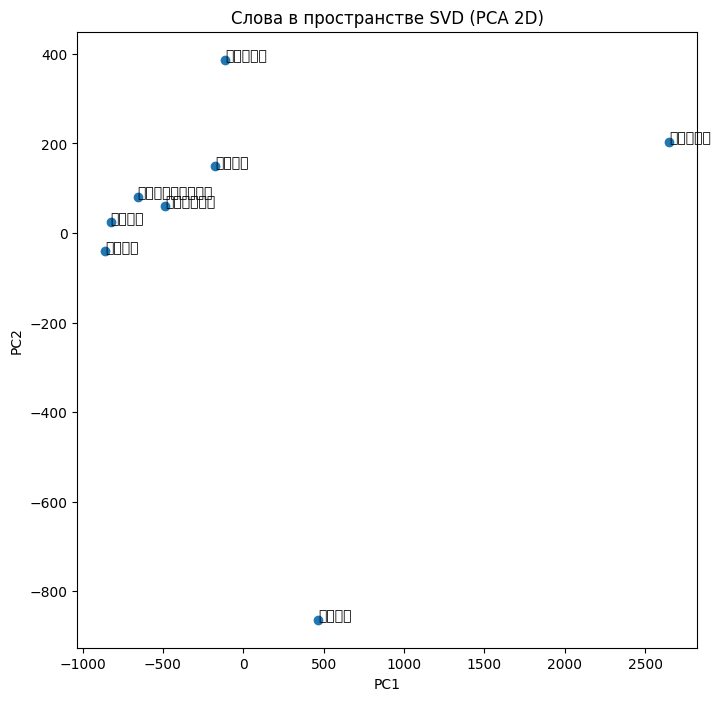

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=0)
vec2d_pca = pca.fit_transform(vectors_subset)

plt.figure(figsize=(8, 8))
plt.scatter(vec2d_pca[:, 0], vec2d_pca[:, 1])

for (x, y), w in zip(vec2d_pca, words_subset):
    plt.text(x, y, w)

plt.title("Слова в пространстве SVD (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [13]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Будем считать, что у тебя уже есть:
# idx2word: list[str]
# word_vectors: np.ndarray shape (V, D)

V = len(index2word)
print("Размер словаря:", V)

# сколько слов вывести фоном
N_BACK = min(400, V)  # можно увеличить до 500

# фоновая выборка слов (например, просто топ по частоте = первые в index2word)
background_words = index2word[:N_BACK]

# маппинг слово -> индекс
word2idx = {w: i for i, w in enumerate(index2word)}

# индексы фоновых слов
background_idx = [word2idx[w] for w in background_words]
background_vecs = word_vectors[background_idx]
background_vecs.shape


Размер словаря: 50000


(400, 300)

In [14]:
pca = PCA(n_components=2, random_state=0)
coords_2d = pca.fit_transform(background_vecs)  # shape: (N_BACK, 2)

# словарь слово -> 2D координата
coords = {w: coords_2d[i] for i, w in enumerate(background_words)}


In [15]:
focus_words = [
    "राजा", "राणी", "मुंबई", "पुणे",
    "सरकार", "मंत्री", "भारत", "पाकिस्तान",
    "शहर", "गाव", "युद्ध", "शांती", "प्रेम",
]

focus_words = [w for w in focus_words if w in coords]
print("Фактически выделяемых слов:", len(focus_words))
focus_words


Фактически выделяемых слов: 3


['मुंबई', 'पुणे', 'शहर']

/var/folders/_r/36z7dtb148d59n241lbfgkkh0000gn/T/ipykernel_49271/1443870258.py:22: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/_r/36z7dtb148d59n241lbfgkkh0000gn/T/ipykernel_49271/1443870258.py:22: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/var/folders/_r/36z7dtb148d59n241lbfgkkh0000gn/T/ipykernel_49271/1443870258.py:22: UserWarning: Glyph 2369 (\N{DEVANAGARI VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/_r/36z7dtb148d59n241lbfgkkh0000gn/T/ipykernel_49271/1443870258.py:22: UserWarning: Glyph 2306 (\N{DEVANAGARI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/_r/36z7dtb148d59n241lbfgkkh0000gn/T/ipykernel_49271/1443870258.py:22: UserWarning: Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/_r/36z7dtb148d59n241lbfgkkh0000gn/T/ipykernel_49

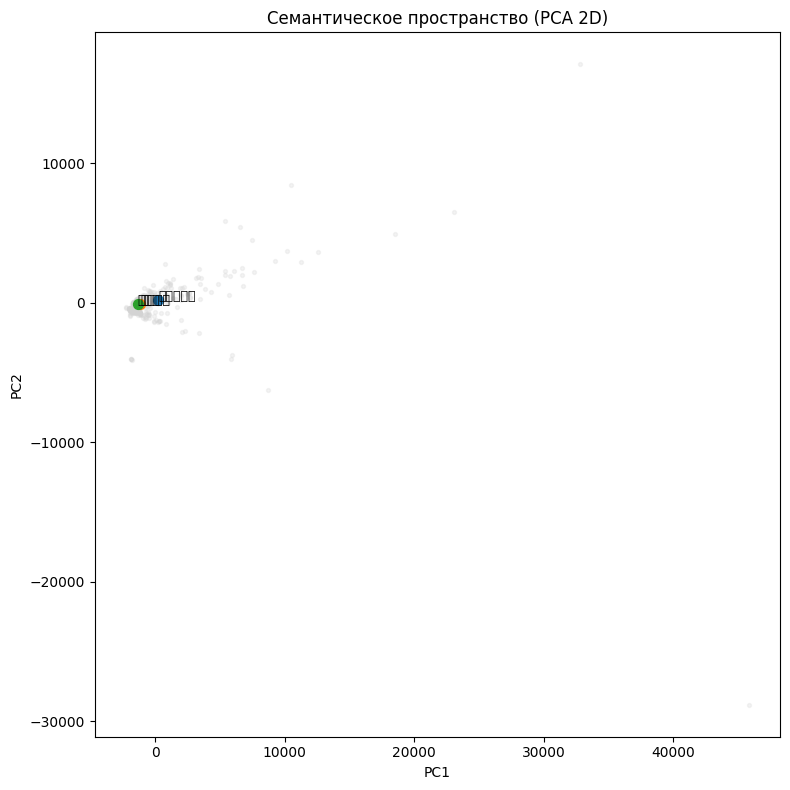

In [16]:
fig, ax = plt.subplots(figsize=(8, 8))

# 1) фон: все слова из background_words
bg_points = np.array([coords[w] for w in background_words])
ax.scatter(
    bg_points[:, 0],
    bg_points[:, 1],
    s=8,              # меньший размер
    alpha=0.25,       # прозрачность
    color="lightgray" # другой цвет
)

# 2) выделенные слова: крупнее, поверх фона
for w in focus_words:
    x, y = coords[w]
    ax.scatter([x], [y], s=50)          # крупная точка
    ax.text(x, y, w, fontsize=9)        # подпись

ax.set_title("Семантическое пространство (PCA 2D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()


In [17]:
import pandas as pd

# словарь переводов для части слов (дополни под себя)
translations = {
    "राजा": "king",
    "राणी": "queen",
    "मुंबई": "Mumbai",
    "पुणे": "Pune",
    "सरकार": "government",
    "मंत्री": "minister",
    "भारत": "India",
    "पाकिस्तान": "Pakistan",
    "शहर": "city",
    "गाव": "village",
    "युद्ध": "war",
    "शांती": "peace",
    "प्रेम": "love",
}

rows = []
for w in background_words:
    x, y = coords[w]
    rows.append(
        {
            "word": w,
            "x": float(x),
            "y": float(y),
            "translation": translations.get(w, ""),
            "is_focus": w in focus_words,
        }
    )

df = pd.DataFrame(rows)
df.head()


,word,x,y,translation,is_focus
0,आहे,45816.875000,-28824.642578,,False
1,या,32754.632812,17103.404297,,False
2,आणि,23030.472656,6512.201172,,False
3,व,18494.408203,4916.837891,,False
4,नाही,5905.828125,-3707.937744,,False
